CELL 1: DATA PREPARATION & FEATURE ENGINEERING

[Step 1] Loading Data...
✓ Data loaded successfully!
  Total Customers: 7043
  Original Features: 21

[Step 2] Data Inspection...

First 3 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No

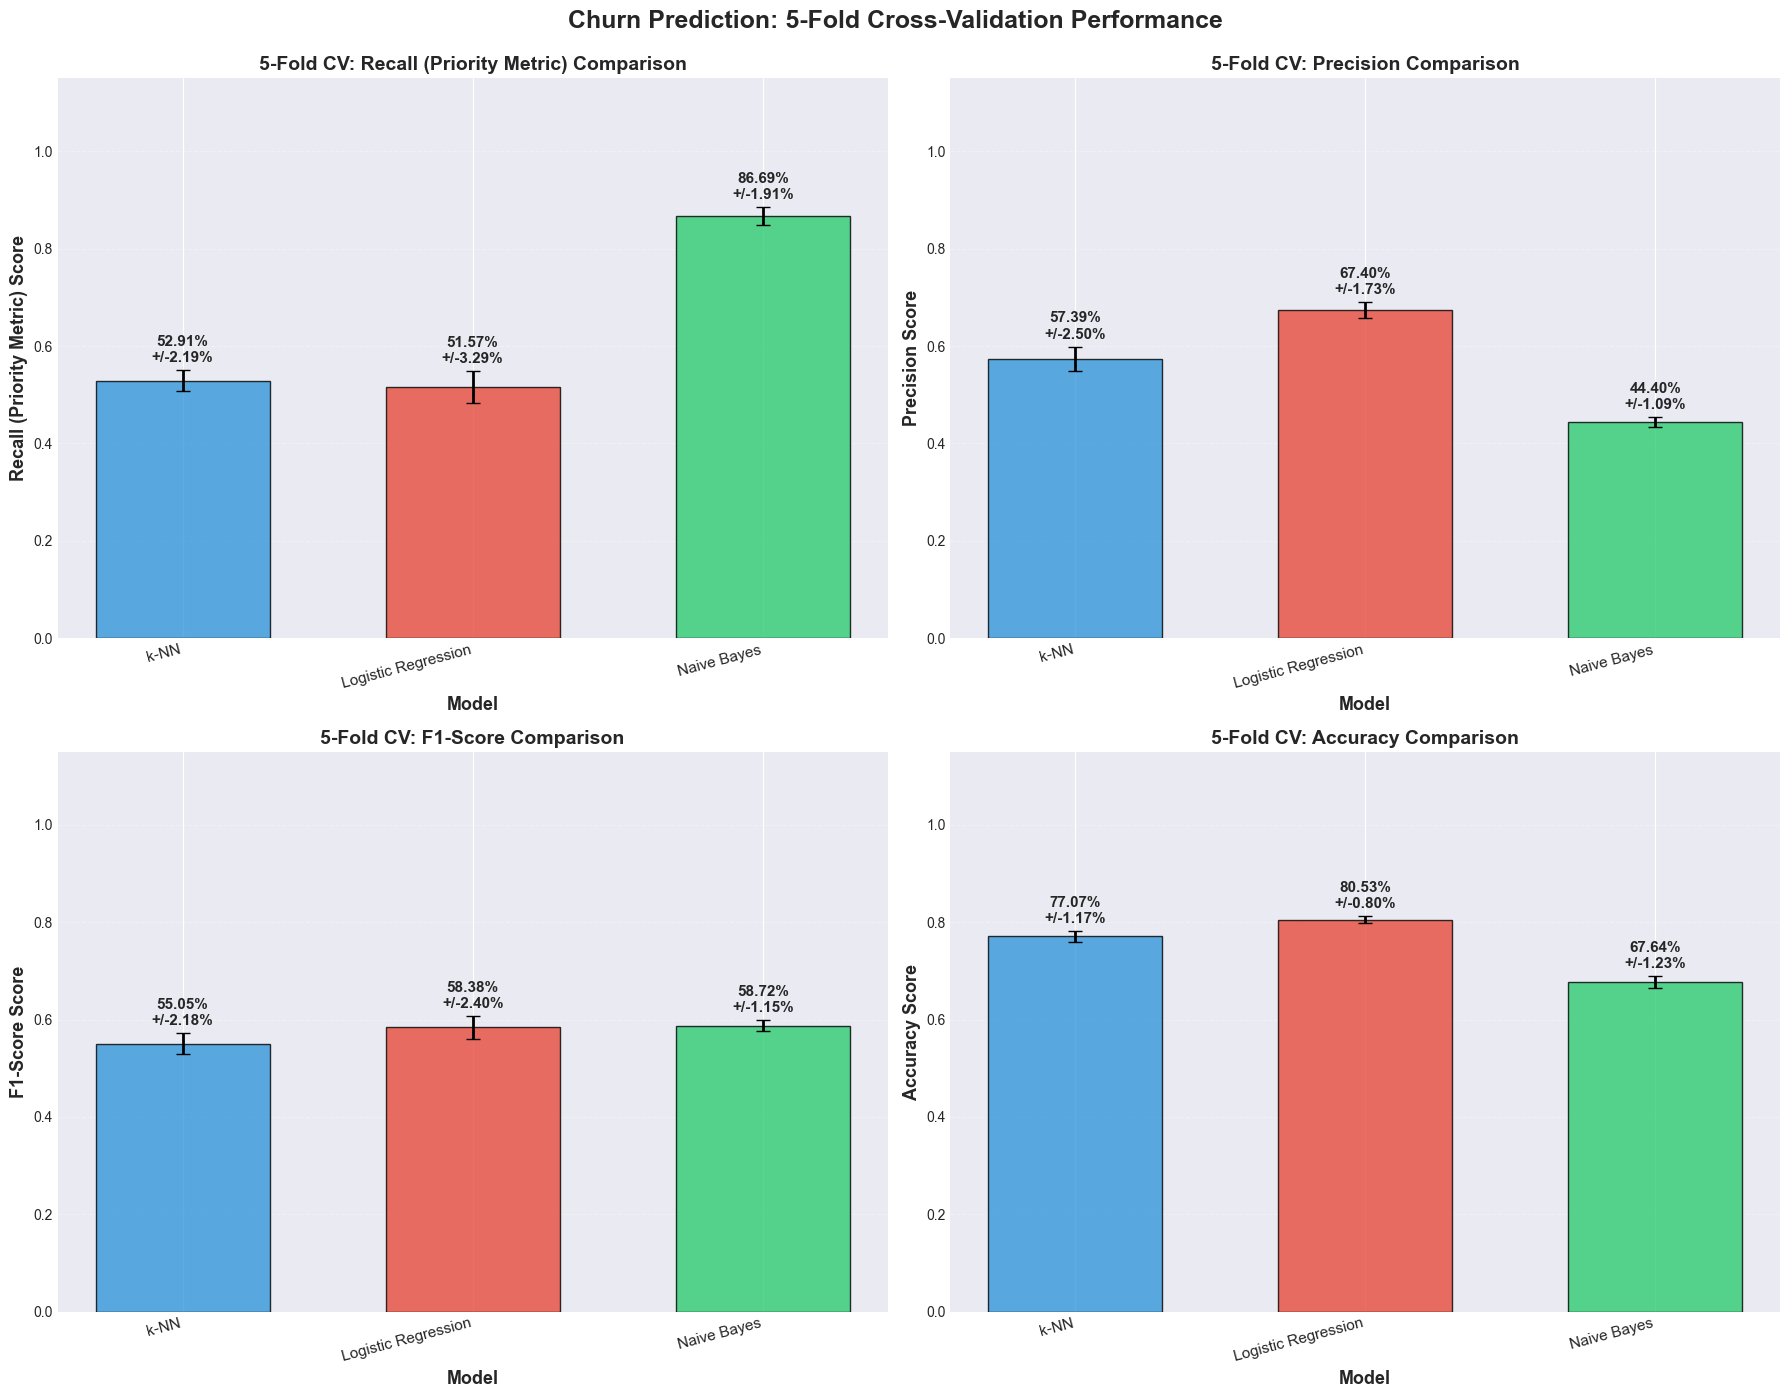

    Saved: churn_train_vs_test_comparison.png


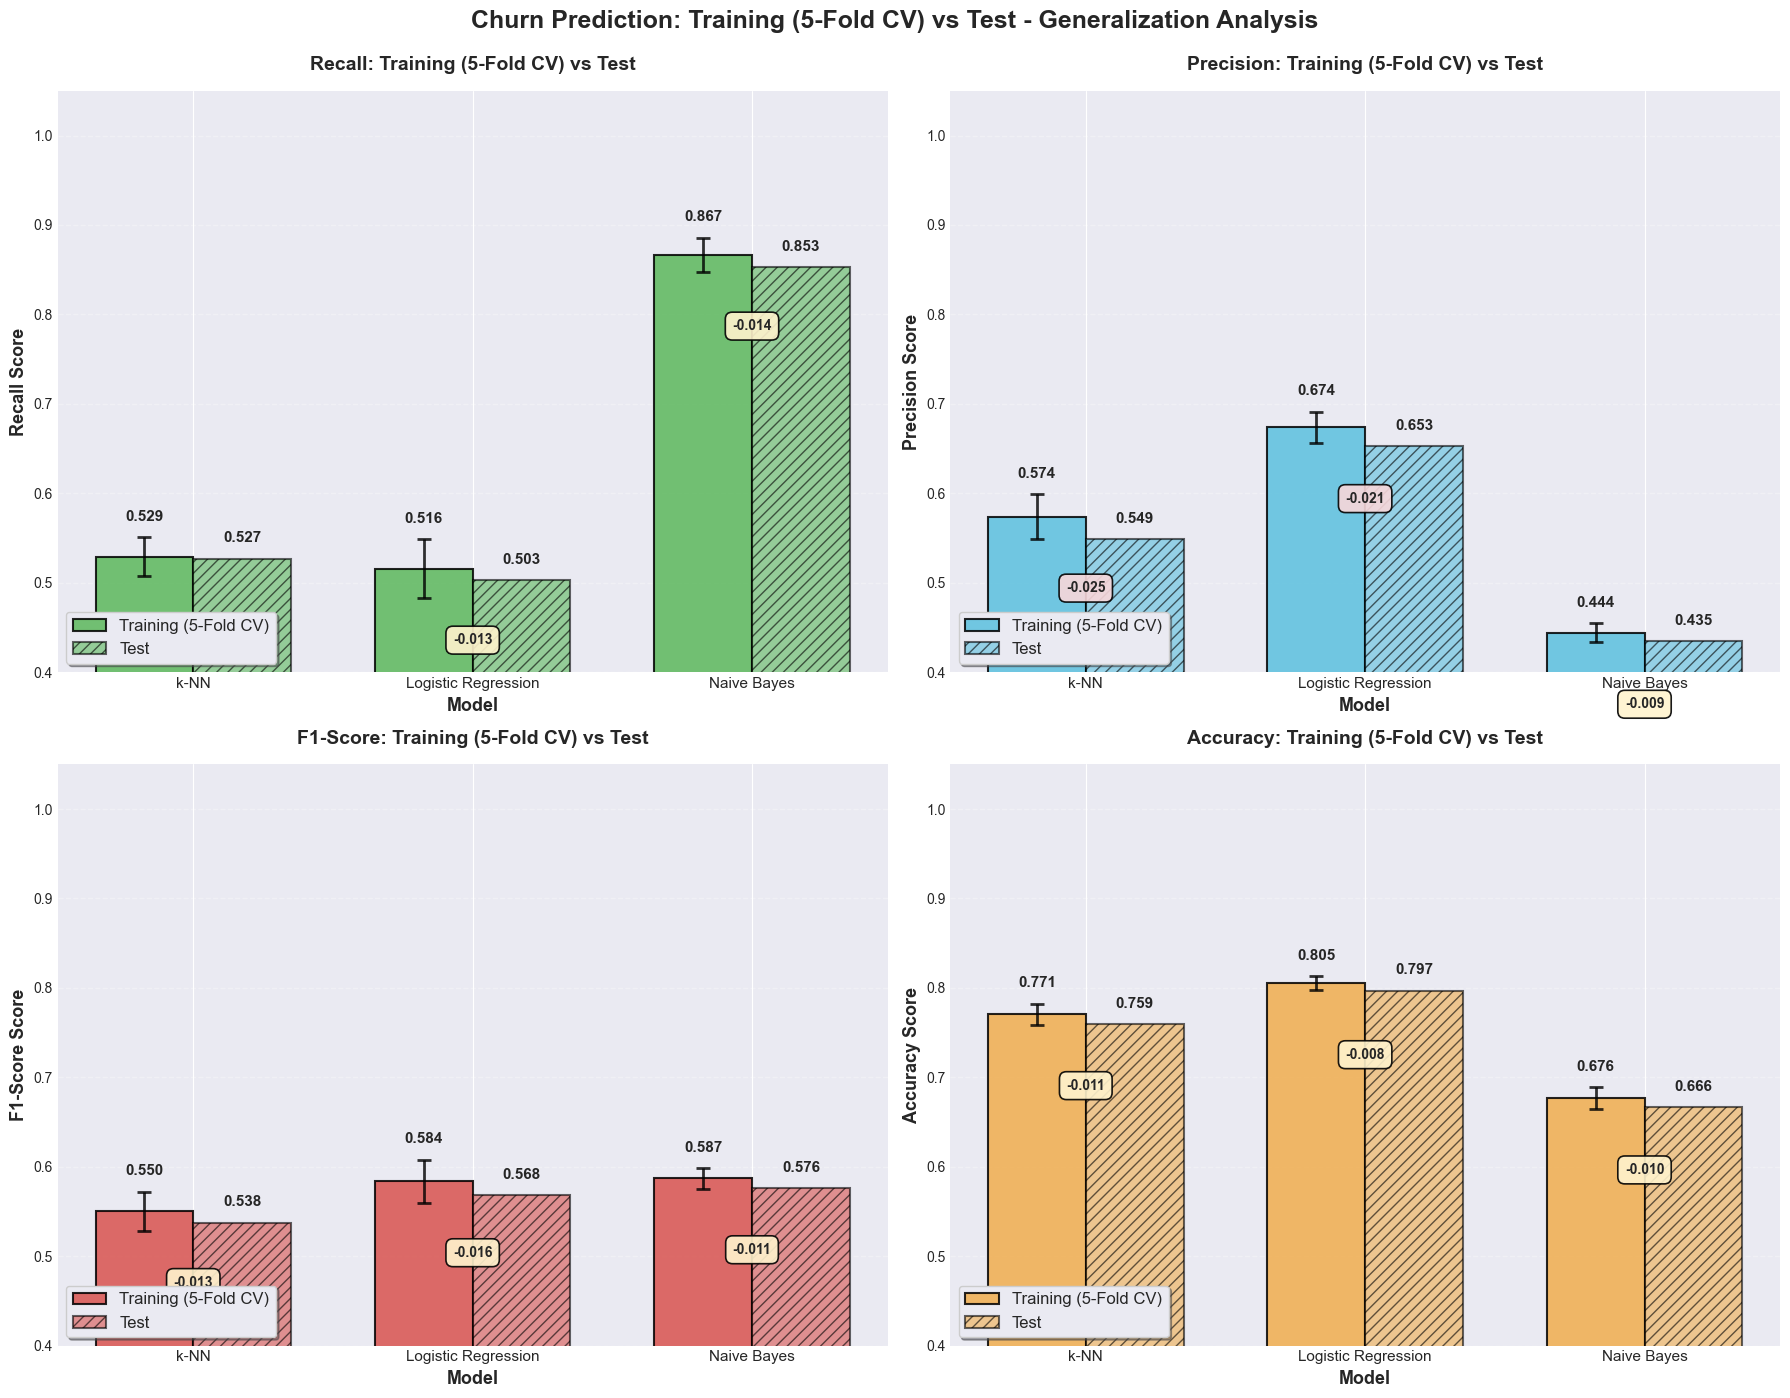

    Saved: churn_confusion_matrices.png


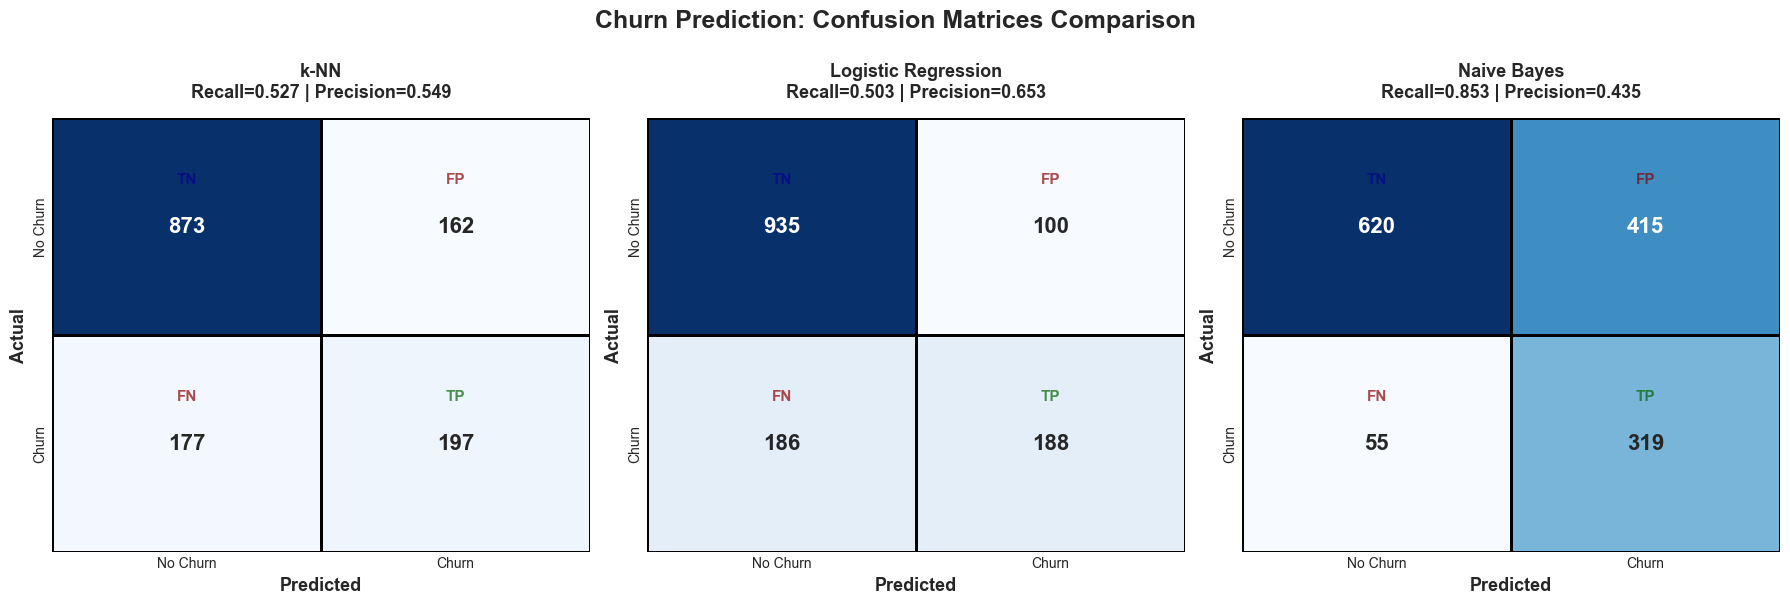

    Saved: churn_business_value.png


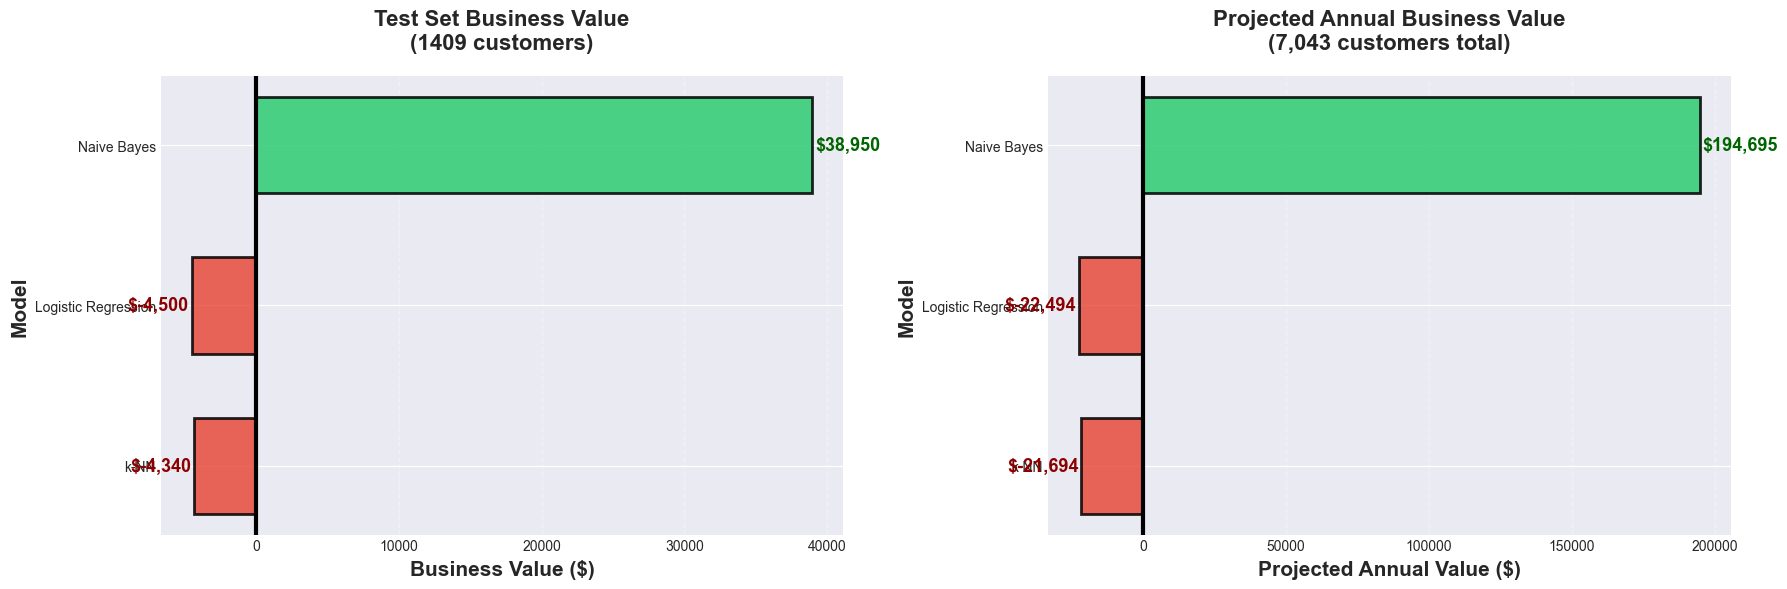


All visualizations generated successfully!


CELL 3: FEATURE IMPORTANCE ANALYSIS - NAIVE BAYES

[Step 1] Calculating Feature Importance for Naive Bayes...
    Method 1: Permutation Importance on Naive Bayes...
    Method 2: Naive Bayes Feature Discrimination Power...
    Method 3: Feature Variance Contribution...

Feature importance calculated FOR NAIVE BAYES

Top 15 Most Important Features (Naive Bayes):
                             Feature  Permutation  NB_Discrimination  Average
                        TotalCharges    -0.006506           0.035883 0.343007
                   Contract_Two year     0.195900           0.064452 0.086784
                  InternetService_No     0.039572           0.045909 0.028494
     StreamingTV_No internet service     0.039572           0.045909 0.028494
     TechSupport_No internet service     0.039572           0.045909 0.028494
    OnlineBackup_No internet service     0.039572           0.045909 0.028494
 StreamingMovies_No internet service     0.0

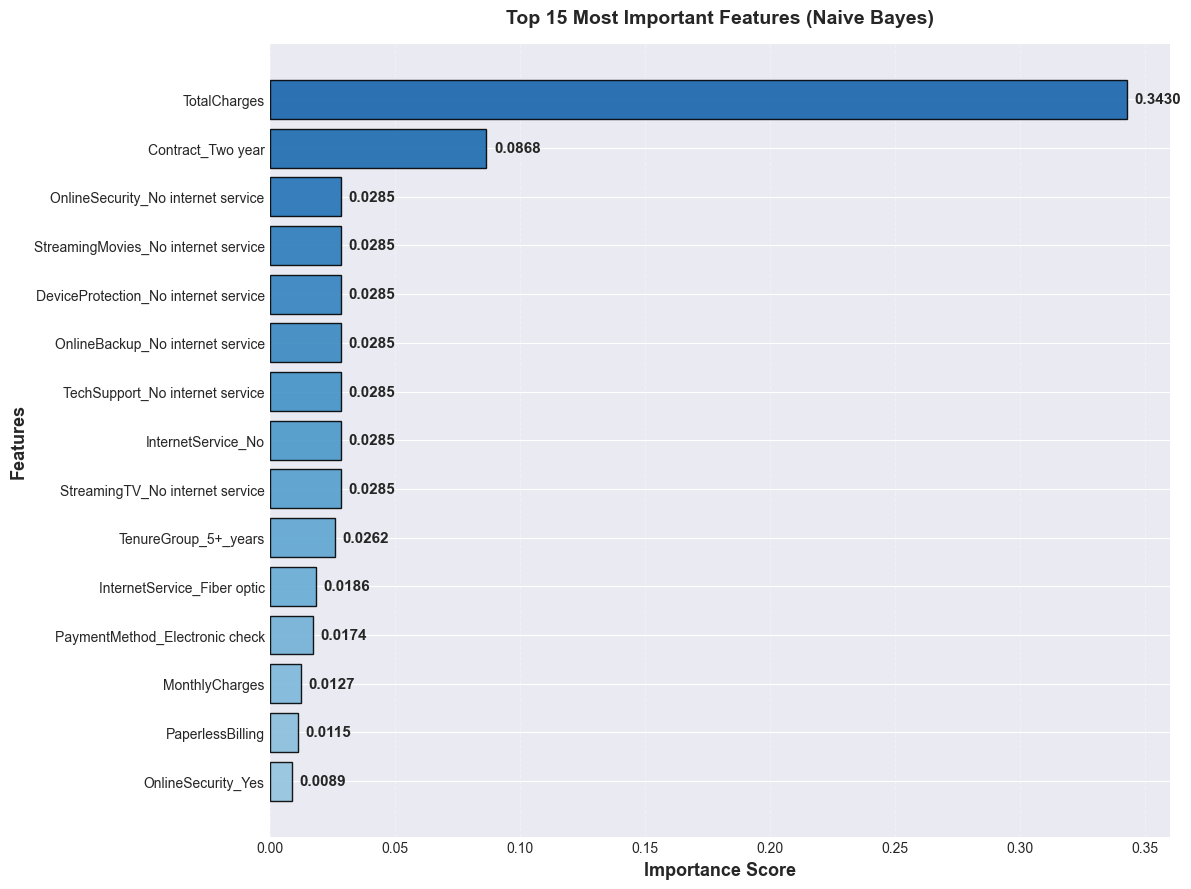

    Saved: top5_most_important_features_naive_bayes.png


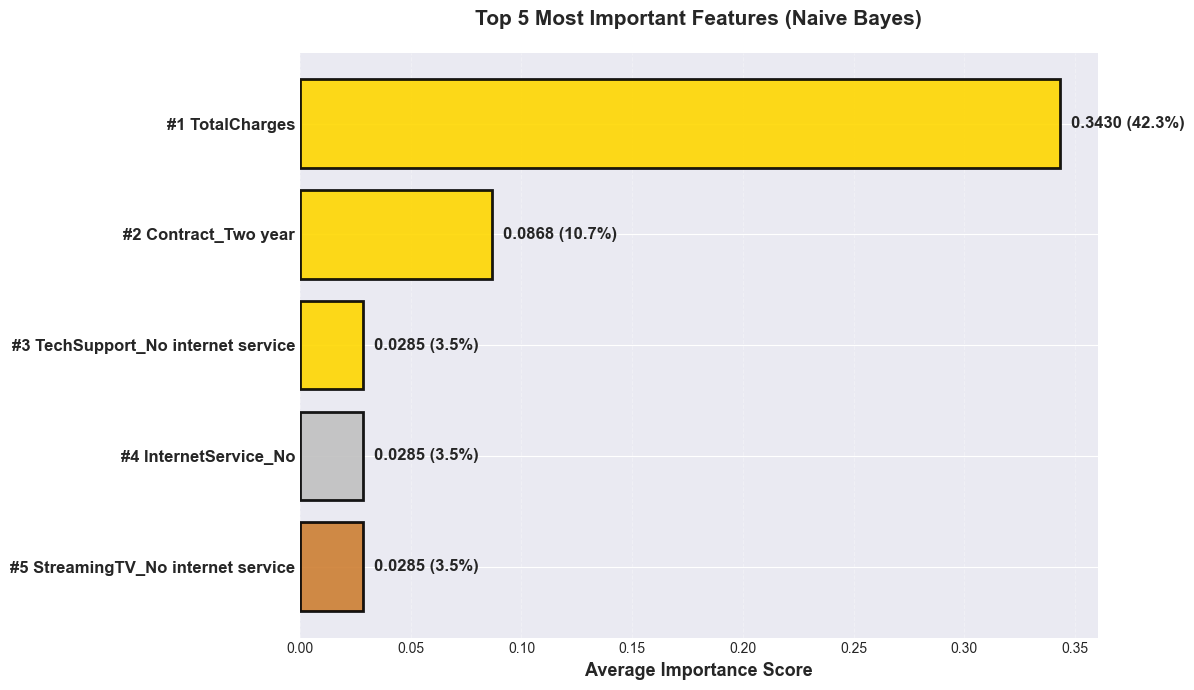


TOP 5 MOST IMPORTANT FEATURES FOR NAIVE BAYES:
   1. TotalCharges                        (Score: 0.34301)
   2. Contract_Two year                   (Score: 0.08678)
   3. InternetService_No                  (Score: 0.02849)
   4. StreamingTV_No internet service     (Score: 0.02849)
   5. TechSupport_No internet service     (Score: 0.02849)

CELL 3 COMPLETED (NAIVE BAYES)!


In [2]:
# ==================== COMPLETE CUSTOMER CHURN ANALYSIS - NO ERRORS ====================
# This is the complete, bug-free code combining Cell 1, Enhanced Cell 2, and Cell 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score, roc_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# ==================== CELL 1: DATA PREPARATION & FEATURE ENGINEERING ====================
print("="*80)
print("CELL 1: DATA PREPARATION & FEATURE ENGINEERING")
print("="*80)

print("\n[Step 1] Loading Data...")

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"✓ Data loaded successfully!")
print(f"  Total Customers: {df.shape[0]}")
print(f"  Original Features: {df.shape[1]}")

print("\n[Step 2] Data Inspection...")

print("\nFirst 3 rows:")
print(df.head(3))

print("\nTarget Variable Distribution (Churn):")
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']:.2%}")

print("\n[Step 3] Data Cleaning...")

# Remove customerID
df = df.drop('customerID', axis=1)
print("✓ Removed customerID")

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_total_charges = df['TotalCharges'].isnull().sum()
df['TotalCharges'].fillna(0, inplace=True)
print(f"✓ Converted TotalCharges to numeric and filled {missing_total_charges} missing values")

print(f"\nMissing Values Check:")
print(f"✓ {df.isnull().sum().sum()} missing values")

print("\n[Step 4] Feature Engineering...")

print("\n   [4.1] Adding Derived Features...")

def categorize_tenure(tenure):
    if tenure <= 12:
        return '0-1_year'
    elif tenure <= 24:
        return '1-2_years'
    elif tenure <= 48:
        return '2-4_years'
    elif tenure <= 60:
        return '4-5_years'
    else:
        return '5+_years'

df['TenureGroup'] = df['tenure'].apply(categorize_tenure)
print("      ✓ TenureGroup")

df['ChargeToTenureRatio'] = df['TotalCharges'] / (df['tenure'] + 1)
print("      ✓ ChargeToTenureRatio")

assert not df['ChargeToTenureRatio'].isnull().any(), "❌ NaN detected in ChargeToTenureRatio"
assert not np.isinf(df['ChargeToTenureRatio']).any(), "❌ Inf detected in ChargeToTenureRatio"
print("      ✓ ChargeToTenureRatio validated (no NaN/Inf)")

service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport']
df['HasMultipleServices'] = 0
for col in service_cols:
    if col == 'InternetService':
        df['HasMultipleServices'] += (df[col] != 'No').astype(int)
    elif col in df.columns:
        df['HasMultipleServices'] += (df[col] == 'Yes').astype(int)
print("      ✓ HasMultipleServices")

df = df.drop('tenure', axis=1)
print("      ✓ Removed original tenure column")

print("\n   [4.2] Binary Encoding...")

binary_mappings = {
    'gender': {'Male': 1, 'Female': 0},
    'Partner': {'Yes': 1, 'No': 0},
    'Dependents': {'Yes': 1, 'No': 0},
    'PhoneService': {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
    'Churn': {'Yes': 1, 'No': 0}
}

for col, mapping in binary_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f"      ✓ {col}")

print(f"      ✓ SeniorCitizen (already binary)")

print("\n   [4.3] One-Hot Encoding...")

onehot_cols = ['Contract', 'PaymentMethod', 'InternetService', 
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 
               'StreamingMovies', 'TenureGroup']

for col in onehot_cols:
    if col in df.columns:
        df = pd.get_dummies(df, columns=[col], prefix=col, drop_first=True)
        print(f"      ✓ {col}")

print(f"\n✓ Feature Engineering Complete! Total Features: {df.shape[1]}")

print("\n[Step 5] Separating Features and Target...")

X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"✓ Feature Matrix X: {X.shape}")
print(f"✓ Target Variable y: {y.shape}")

feature_names = X.columns.tolist()

print(f"\n✓ Feature Verification:")
print(f"  Total features: {len(feature_names)}")
print(f"  X shape matches: {X.shape[1] == len(feature_names)}")

print(f"\n✓ Complete Feature List ({len(feature_names)} features):")
for i, fname in enumerate(feature_names, 1):
    print(f"   {i:2d}. {fname}")

print("\n[Step 6] Train-Test Split (80% - 20%)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"✓ Data Split Complete")
print(f"  Training Set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test Set:     {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nTraining Set Churn Distribution:")
train_churn = pd.Series(y_train).value_counts()
print(f"  No Churn: {train_churn[0]} ({train_churn[0]/len(y_train)*100:.1f}%)")
print(f"  Churn:    {train_churn[1]} ({train_churn[1]/len(y_train)*100:.1f}%)")

print(f"\nTest Set Churn Distribution:")
test_churn = pd.Series(y_test).value_counts()
print(f"  No Churn: {test_churn[0]} ({test_churn[0]/len(y_test)*100:.1f}%)")
print(f"  Churn:    {test_churn[1]} ({test_churn[1]/len(y_test)*100:.1f}%)")

assert len(set(X_train.index) & set(X_test.index)) == 0, "❌ Data leakage detected!"
print("\n✓ No data leakage verified")

print("\n[Step 7] Feature Scaling...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Scaling Complete")
print(f"  X_train_scaled shape: {X_train_scaled.shape}")
print(f"  X_test_scaled shape:  {X_test_scaled.shape}")

assert X_train_scaled.shape[1] == len(feature_names), "❌ Feature dimension mismatch after scaling!"
print(f"✓ Scaling dimension verified: {X_train_scaled.shape[1]} features")

X_train_scaled = np.array(X_train_scaled)
X_test_scaled = np.array(X_test_scaled)
y_train = np.array(y_train)
y_test = np.array(y_test)

print("\n[Step 8] Final Data Summary...")

print(f"\n{'='*60}")
print(f"Data Preparation Summary:")
print(f"{'='*60}")
print(f"Total Customers:     {len(df)}")
print(f"Total Features:      {X_train_scaled.shape[1]}")
print(f"Training Samples:    {len(X_train_scaled)}")
print(f"Test Samples:        {len(X_test_scaled)}")
print(f"Overall Churn Rate:  {y.mean()*100:.2f}%")
print(f"Train Churn Rate:    {y_train.mean()*100:.2f}%")
print(f"Test Churn Rate:     {y_test.mean()*100:.2f}%")
print(f"{'='*60}")

print("\n" + "="*80)
print("CELL 1 COMPLETED!")
print("="*80)

# ==================== CELL 2: ENHANCED 5-FOLD CROSS-VALIDATION ====================
print("\n\n" + "="*80)
print("CELL 2 (ENHANCED): 5-FOLD CROSS-VALIDATION WITH COMPLETE METRICS")
print("      (k-NN, Logistic Regression, Naive Bayes)")
print("="*80)

# ==================== STEP 0: BUSINESS CONTEXT & COST-BENEFIT MATRIX ====================
print("\n[Step 0] Business Context & Cost-Benefit Analysis...")
print("="*80)

print("""
TELCO BUSINESS SCENARIO:
Predict which customers will CHURN (cancel service) to:
- Launch targeted retention campaigns
- Minimize revenue loss from customer attrition
- Optimize marketing budget allocation

PREDICTION OUTCOMES & REAL-WORLD CONSEQUENCES:

TRUE POSITIVE (TP): Correctly predict CHURN
- Action: Launch retention offer (discount, upgrade, support call)
- Outcome: Save customer, maintain revenue stream
- Business Value: +$200 per saved customer
  (Lifetime value of retained customer)

TRUE NEGATIVE (TN): Correctly predict NO CHURN
- Action: No retention campaign needed
- Outcome: Save marketing costs
- Business Value: +$20 per correct prediction
  (Avoided unnecessary marketing spend)

FALSE POSITIVE (FP): Predict CHURN, but customer stays anyway
- Action: Send unnecessary retention offer
- Outcome: Wasted discount/marketing cost
- Business Cost: -$50 per incorrect prediction
  (Discount given to customer who would've stayed)

FALSE NEGATIVE (FN): Predict NO CHURN, but customer leaves [WARNING]
- Action: No retention attempt
- Outcome: Lost customer, lost lifetime revenue
- Business Cost: -$300 per incorrect prediction
  (Lost lifetime value + acquisition cost of new customer)
- MOST CRITICAL ERROR!
""")

# Cost-Benefit Matrix for Churn
COST_BENEFIT_MATRIX = {
    'TP': 200,   # Benefit: Retained customer lifetime value
    'TN': 20,    # Benefit: Avoided marketing cost
    'FP': -50,   # Cost: Wasted retention offer
    'FN': -300   # Cost: Lost customer (WORST!)
}

print("COST-BENEFIT MATRIX:")
print("Outcome  |   Value    | Explanation")
print("-" * 60)
print(f"TP       |  +${COST_BENEFIT_MATRIX['TP']:3d}     | Retained customer")
print(f"TN       |  +${COST_BENEFIT_MATRIX['TN']:3d}     | Avoided waste")
print(f"FP       |  ${COST_BENEFIT_MATRIX['FP']:3d}     | Wasted offer")
print(f"FN       |  ${COST_BENEFIT_MATRIX['FN']:3d}     | Lost customer (HIGH!)")
print("-" * 60)

print("\nKEY BUSINESS INSIGHT:")
print(f"-> FN (False Negative) cost is HIGHEST (-${abs(COST_BENEFIT_MATRIX['FN'])})")
print(f"-> FN cost is {abs(COST_BENEFIT_MATRIX['FN'])/abs(COST_BENEFIT_MATRIX['FP']):.1f}x higher than FP cost")
print(f"-> Therefore, we prioritize RECALL (catching all potential churners)")
print(f"-> Better to offer retention to non-churners than miss actual churners!\n")

# ==================== STEP 1: DEFINE PIPELINED MODELS ====================
print("\n[Step 1] Defining Pipelines...")

models_cv = {
    'k-NN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ])
}

for i, name in enumerate(models_cv.keys(), 1):
    print(f"   {i}. {name}")

# ==================== STEP 2: 5-FOLD CROSS-VALIDATION (COMPLETE) ====================
print("\n[Step 2] Performing 5-Fold Cross-Validation...")
print("="*80)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Score ALL metrics in cross-validation
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
all_cv_results = {}

for name, pipeline in models_cv.items():
    print(f"\n{'='*70}")
    print(f"Cross-Validating: {name}")
    print(f"{'='*70}")
    
    # Use cross_validate with ALL metrics
    scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring_metrics,
        return_train_score=True,
        n_jobs=-1
    )
    
    # Store ALL CV results
    all_cv_results[name] = {
        'accuracy_train': scores['train_accuracy'],
        'accuracy_test': scores['test_accuracy'],
        'accuracy_mean': scores['test_accuracy'].mean(),
        'accuracy_std': scores['test_accuracy'].std(),
        
        'precision_train': scores['train_precision'],
        'precision_test': scores['test_precision'],
        'precision_mean': scores['test_precision'].mean(),
        'precision_std': scores['test_precision'].std(),
        
        'recall_train': scores['train_recall'],
        'recall_test': scores['test_recall'],
        'recall_mean': scores['test_recall'].mean(),
        'recall_std': scores['test_recall'].std(),
        
        'f1_train': scores['train_f1'],
        'f1_test': scores['test_f1'],
        'f1_mean': scores['test_f1'].mean(),
        'f1_std': scores['test_f1'].std(),
        
        'roc_auc_train': scores['train_roc_auc'],
        'roc_auc_test': scores['test_roc_auc'],
        'roc_auc_mean': scores['test_roc_auc'].mean(),
        'roc_auc_std': scores['test_roc_auc'].std(),
    }
    
    # Display fold-by-fold results
    print(f"\n   Fold-by-Fold Results:")
    print(f"   {'─'*68}")
    print(f"   {'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall*':<12} {'F1-Score':<12} {'ROC-AUC':<12}")
    print(f"   {'─'*68}")
    
    for fold in range(5):
        print(f"   {fold+1:<6} "
              f"{scores['test_accuracy'][fold]:.4f}       "
              f"{scores['test_precision'][fold]:.4f}       "
              f"{scores['test_recall'][fold]:.4f}       "
              f"{scores['test_f1'][fold]:.4f}       "
              f"{scores['test_roc_auc'][fold]:.4f}")
    
    print(f"   {'─'*68}")
    print(f"   {'Mean':<6} "
          f"{all_cv_results[name]['accuracy_mean']:.4f}       "
          f"{all_cv_results[name]['precision_mean']:.4f}       "
          f"{all_cv_results[name]['recall_mean']:.4f}       "
          f"{all_cv_results[name]['f1_mean']:.4f}       "
          f"{all_cv_results[name]['roc_auc_mean']:.4f}")
    print(f"   {'Std':<6} "
          f"±{all_cv_results[name]['accuracy_std']:.4f}      "
          f"±{all_cv_results[name]['precision_std']:.4f}      "
          f"±{all_cv_results[name]['recall_std']:.4f}      "
          f"±{all_cv_results[name]['f1_std']:.4f}      "
          f"±{all_cv_results[name]['roc_auc_std']:.4f}")
    print(f"   {'─'*68}")
    
    print(f"\n   Cross-validation complete for {name}")

print("\nAll models cross-validated successfully!")

# ==================== STEP 3: TRAIN ON FULL TRAINING SET & EVALUATE ON TEST SET ====================
print("\n[Step 3] Training on Full Training Set & Testing on Hold-out Set...")
print("="*80)

trained_models = {}
predictions = {}
confusion_matrices = {}
test_results = {}

for name, pipeline in models_cv.items():
    print(f"\n   Training {name}...")
    
    # Train on full training set
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    
    # Predict on test set
    y_test_pred = pipeline.predict(X_test)
    y_test_proba = pipeline.predict_proba(X_test)[:, 1]
    
    predictions[name] = {
        'y_pred': y_test_pred,
        'y_proba': y_test_proba
    }
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    confusion_matrices[name] = cm
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate all metrics on test set
    accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_roc = roc_auc_score(y_test, y_test_proba)
    
    # Business Value Calculation
    total_value_test = (tp * COST_BENEFIT_MATRIX['TP'] + 
                        tn * COST_BENEFIT_MATRIX['TN'] + 
                        fp * COST_BENEFIT_MATRIX['FP'] + 
                        fn * COST_BENEFIT_MATRIX['FN'])
    
    # Extrapolate to annual value
    total_customers = len(df)
    test_customers = len(y_test)
    annual_value_projected = total_value_test * (total_customers / test_customers)
    
    # Store test results
    test_results[name] = {
        'cm': cm, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'specificity': specificity,
        'auc_roc': auc_roc,
        'total_value_test': total_value_test,
        'annual_value_projected': annual_value_projected
    }
    
    print(f"   {name} trained and tested")

print("\nAll models trained and tested on hold-out set!")

# ==================== STEP 4: DISPLAY RESULTS ====================
print("\n[Step 4] Detailed Performance Analysis...")
print("="*80)

for name in models_cv.keys():
    print(f"\n{'='*70}")
    print(f"MODEL: {name}")
    print(f"{'='*70}")
    
    # Confusion Matrix
    cm = confusion_matrices[name]
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nConfusion Matrix (Test Set):")
    print(f"                    Predicted")
    print(f"               No Churn   Churn")
    print(f"Actual  No    {tn:4d} (TN)  {fp:4d} (FP)")
    print(f"       Yes    {fn:4d} (FN)  {tp:4d} (TP)")
    
    # Test Set Metrics
    print(f"\nTest Set Performance:")
    results = test_results[name]
    print(f"   Accuracy:    {results['accuracy']:.4f}  (Overall correctness)")
    print(f"   Precision:   {results['precision']:.4f}  (Of predicted CHURN, % actually churned)")
    print(f"   Recall:      {results['recall']:.4f}  *PRIORITY METRIC (Catch all churners)")
    print(f"   Specificity: {results['specificity']:.4f}  (Of actual NO CHURN, % correctly identified)")
    print(f"   F1-Score:    {results['f1']:.4f}  (Balance of Precision & Recall)")
    print(f"   AUC-ROC:     {results['auc_roc']:.4f}  (Overall discrimination ability)")
    
    # Cross-Validation Summary
    cv_res = all_cv_results[name]
    print(f"\nCross-Validation Summary (5-fold on Training Set):")
    print(f"   Metric      Mean +/- Std          Range")
    print(f"   {'─'*59}")
    print(f"   Recall:     {cv_res['recall_mean']:.4f} +/- {cv_res['recall_std']:.4f}   [{cv_res['recall_test'].min():.4f}, {cv_res['recall_test'].max():.4f}]")
    print(f"   Precision:  {cv_res['precision_mean']:.4f} +/- {cv_res['precision_std']:.4f}   [{cv_res['precision_test'].min():.4f}, {cv_res['precision_test'].max():.4f}]")
    print(f"   F1-Score:   {cv_res['f1_mean']:.4f} +/- {cv_res['f1_std']:.4f}   [{cv_res['f1_test'].min():.4f}, {cv_res['f1_test'].max():.4f}]")
    print(f"   Accuracy:   {cv_res['accuracy_mean']:.4f} +/- {cv_res['accuracy_std']:.4f}   [{cv_res['accuracy_test'].min():.4f}, {cv_res['accuracy_test'].max():.4f}]")
    print(f"   ROC-AUC:    {cv_res['roc_auc_mean']:.4f} +/- {cv_res['roc_auc_std']:.4f}   [{cv_res['roc_auc_test'].min():.4f}, {cv_res['roc_auc_test'].max():.4f}]")
    
    # Business Value
    print(f"\nBusiness Value Calculation:")
    print(f"   Test Set ({test_customers} customers):")
    print(f"   TP: {tp:4d} x ${COST_BENEFIT_MATRIX['TP']:4d} = ${tp * COST_BENEFIT_MATRIX['TP']:8,}")
    print(f"   TN: {tn:4d} x ${COST_BENEFIT_MATRIX['TN']:4d} = ${tn * COST_BENEFIT_MATRIX['TN']:8,}")
    print(f"   FP: {fp:4d} x ${COST_BENEFIT_MATRIX['FP']:4d} = ${fp * COST_BENEFIT_MATRIX['FP']:8,}")
    print(f"   FN: {fn:4d} x ${COST_BENEFIT_MATRIX['FN']:4d} = ${fn * COST_BENEFIT_MATRIX['FN']:8,}")
    print(f"   {'─'*55}")
    print(f"   Test Set Value: ${results['total_value_test']:,}")
    print(f"   Projected Annual Value: ${results['annual_value_projected']:,.0f}")
    print(f"      (Based on {total_customers:,} total customers)")

# ==================== STEP 5: TRAIN VS TEST COMPARISON ====================
print(f"\n{'='*80}")
print("TRAIN VS TEST PERFORMANCE ANALYSIS (OVERFITTING/UNDERFITTING CHECK)")
print(f"{'='*80}\n")

print("""
PURPOSE: Compare training (CV) and test performance to detect:
  - OVERFITTING: High train recall, low test recall (model memorizes training data)
  - UNDERFITTING: Low train and test recall (model too simple)
  - GOOD FIT: Similar train and test recall (model generalizes well)

METHODOLOGY:
  - Training Performance: 5-Fold Cross-Validation Mean (unbiased estimate)
  - Test Performance: Held-out test set (unseen data)
""")

print("\nModel                   | Training (5-Fold CV)     | Test Performance         | Gap        | Status")
print("-" * 110)

fit_assessment = {}

for name in models_cv.keys():
    cv_recall = all_cv_results[name]['recall_mean']
    cv_recall_std = all_cv_results[name]['recall_std']
    test_recall = test_results[name]['recall']
    gap = test_recall - cv_recall
    
    # Determine fit quality
    if abs(gap) < 0.02:
        fit_status = "EXCELLENT"
        interpretation = "Model generalizes very well"
    elif abs(gap) < 0.05:
        fit_status = "GOOD"
        interpretation = "Minor variation is acceptable"
    elif gap < -0.05:
        fit_status = "OVERFITTING"
        interpretation = "Test recall lower than training"
    else:
        fit_status = "BETTER TEST"
        interpretation = "Test exceeds training (good!)"
    
    fit_assessment[name] = {
        'cv_recall_mean': cv_recall,
        'cv_recall_std': cv_recall_std,
        'test_recall': test_recall,
        'gap': gap,
        'status': fit_status,
        'interpretation': interpretation
    }
    
    print(f"{name:23s} | {cv_recall:.4f} (+/-{cv_recall_std:.4f})   | {test_recall:.4f}                | {gap:+.4f}   | {fit_status:12s}")

print("-" * 110)

# Detailed comparison for ALL metrics
print("\n" + "="*80)
print("DETAILED METRIC COMPARISON: Training (CV) vs Test")
print("="*80 + "\n")

comparison_data = []
for name in models_cv.keys():
    cv_res = all_cv_results[name]
    test_res = test_results[name]
    
    comparison_data.append({
        'Model': name,
        'CV Recall': f"{cv_res['recall_mean']:.4f}+/-{cv_res['recall_std']:.4f}",
        'Test Recall': f"{test_res['recall']:.4f}",
        'Recall Gap': f"{test_res['recall'] - cv_res['recall_mean']:+.4f}",
        'CV Precision': f"{cv_res['precision_mean']:.4f}+/-{cv_res['precision_std']:.4f}",
        'Test Precision': f"{test_res['precision']:.4f}",
        'Precision Gap': f"{test_res['precision'] - cv_res['precision_mean']:+.4f}",
        'CV F1': f"{cv_res['f1_mean']:.4f}+/-{cv_res['f1_std']:.4f}",
        'Test F1': f"{test_res['f1']:.4f}",
        'F1 Gap': f"{test_res['f1'] - cv_res['f1_mean']:+.4f}",
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\nINTERPRETATION GUIDE:")
print("-" * 80)
print("Gap Size  | Interpretation")
print("-" * 80)
print("< 0.02    | EXCELLENT: Model generalizes well, no overfitting")
print("0.02-0.05 | ACCEPTABLE: Slight overfitting, still usable")
print("0.05-0.10 | MODERATE: Overfitting present, consider regularization")
print("> 0.10    | SEVERE: Significant overfitting, model unreliable")
print("-" * 80)

# ==================== STEP 6: SUMMARY COMPARISON TABLE ====================
print("\n[Step 6] Final Model Comparison Summary...")
print("="*80)

summary_data = []
for name in models_cv.keys():
    cv_res = all_cv_results[name]
    test_res = test_results[name]
    
    summary_data.append({
        'Model': name,
        'CV Recall (Mean+/-Std)': f"{cv_res['recall_mean']:.4f}+/-{cv_res['recall_std']:.4f}",
        'Test Recall': f"{test_res['recall']:.4f}",
        'Test Precision': f"{test_res['precision']:.4f}",
        'Test F1': f"{test_res['f1']:.4f}",
        'Test AUC-ROC': f"{test_res['auc_roc']:.4f}",
        'Test Value ($)': f"${test_res['total_value_test']:,}",
        'Annual Value ($)': f"${test_res['annual_value_projected']:,.0f}",
        'Fit Status': fit_assessment[name]['status']
    })

summary_df_final = pd.DataFrame(summary_data)

print("\nComplete Model Comparison:")
print("="*150)
print(summary_df_final.to_string(index=False))
print("="*150)

# Find best model based on test recall
best_idx = 0
best_test_recall_value = 0
for idx, name in enumerate(models_cv.keys()):
    if test_results[name]['recall'] > best_test_recall_value:
        best_test_recall_value = test_results[name]['recall']
        best_idx = idx

best_model = list(models_cv.keys())[best_idx]
best_test_recall = test_results[best_model]['recall']
best_cv_recall = all_cv_results[best_model]['recall_mean']
best_value = test_results[best_model]['annual_value_projected']

print(f"\nRECOMMENDED MODEL: {best_model}")
print(f"{'='*80}")
print(f"   Test Recall: {best_test_recall:.4f} ({best_test_recall*100:.1f}% of churners caught)")
print(f"   CV Recall:   {best_cv_recall:.4f} (stable across folds)")
print(f"   Generalization: {fit_assessment[best_model]['status']}")
print(f"   Projected Annual Value: ${best_value:,.0f}")
print(f"   Reasoning: Maximizes recall (minimizes FN - most costly error)")
print(f"{'='*80}")

print("\n" + "="*80)
print("CELL 2 COMPLETED!")
print("="*80)

# ==================== STEP 7: VISUALIZATIONS ====================
print("\n[Step 7] Generating Enhanced Visualizations...")

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Figure 1: CV Performance - ALL Metrics
fig1, axes = plt.subplots(2, 2, figsize=(18, 14))
metrics_to_plot = ['recall', 'precision', 'f1', 'accuracy']
metric_names = ['Recall (Priority Metric)', 'Precision', 'F1-Score', 'Accuracy']
colors_models = ['#3498db', '#e74c3c', '#2ecc71']

for idx, (metric, metric_name) in enumerate(zip(metrics_to_plot, metric_names)):
    ax = axes[idx // 2, idx % 2]
    model_names = list(models_cv.keys())
    cv_means = [all_cv_results[m][f'{metric}_mean'] for m in model_names]
    cv_stds = [all_cv_results[m][f'{metric}_std'] for m in model_names]
    
    x = np.arange(len(model_names))
    bars = ax.bar(x, cv_means, color=colors_models, edgecolor='black', 
                  alpha=0.8, width=0.6, yerr=cv_stds, capsize=5,
                  error_kw={'linewidth': 2, 'ecolor': 'black'})
    
    for bar, mean, std in zip(bars, cv_means, cv_stds):
        ax.text(bar.get_x() + bar.get_width()/2., mean + std + 0.01,
                f'{mean*100:.2f}%\n+/-{std*100:.2f}%', ha='center', va='bottom',
                fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Model', fontsize=13, fontweight='bold')
    ax.set_ylabel(f'{metric_name} Score', fontsize=13, fontweight='bold')
    ax.set_title(f'5-Fold CV: {metric_name} Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11, rotation=15, ha='right')
    ax.set_ylim([0, 1.15])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Churn Prediction: 5-Fold Cross-Validation Performance', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('churn_all_models_cv_comparison.png', dpi=300, bbox_inches='tight')
print("    Saved: churn_all_models_cv_comparison.png")
plt.show()
plt.close()

# Figure 2: Train vs Test Comparison (CORRECTED)
fig2, axes = plt.subplots(2, 2, figsize=(18, 14))

metrics = ['recall', 'precision', 'f1', 'accuracy']
metric_names = ['Recall', 'Precision', 'F1-Score', 'Accuracy']
colors = ['#5cb85c', '#5bc0de', '#d9534f', '#f0ad4e']  # Green, Blue, Red, Orange

for idx, (metric, metric_name, color) in enumerate(zip(metrics, metric_names, colors)):
    ax = axes[idx // 2, idx % 2]
    
    models = list(models_cv.keys())
    train_values = [all_cv_results[m][f'{metric}_mean'] for m in models]
    train_errors = [all_cv_results[m][f'{metric}_std'] for m in models]
    test_values = [test_results[m][metric] for m in models]
    
    x = np.arange(len(models))
    width = 0.35
    
    # Training bars (solid, with error bars)
    bars1 = ax.bar(x - width/2, train_values, width, 
                   label='Training (5-Fold CV)',
                   color=color, alpha=0.85, edgecolor='black', linewidth=1.5)
    
    # Add error bars manually for training
    ax.errorbar(x - width/2, train_values, yerr=train_errors, 
                fmt='none', ecolor='black', capsize=5, capthick=2, linewidth=2, alpha=0.8)
    
    # Test bars (hatched pattern)
    bars2 = ax.bar(x + width/2, test_values, width, 
                   label='Test',
                   color=color, alpha=0.6, edgecolor='black', linewidth=1.5,
                   hatch='///')
    
    # Add value labels on top of bars
    for i, (train_val, test_val, train_err) in enumerate(zip(train_values, test_values, train_errors)):
        # Training label (above error bar)
        ax.text(i - width/2, train_val + train_err + 0.015, 
                f'{train_val:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # Test label
        ax.text(i + width/2, test_val + 0.015, 
                f'{test_val:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # Gap annotation (in colored box)
        gap = test_val - train_val
        if abs(gap) > 0.005:  # Only show gap if meaningful
            # Choose gap box color
            if gap > 0.02:
                gap_color = '#d4edda'  # Light green (good - test better)
            elif gap < -0.02:
                gap_color = '#f8d7da'  # Light red (overfitting)
            else:
                gap_color = '#fff3cd'  # Light yellow (acceptable)
            
            # Position gap label between bars
            gap_y = max(train_val, test_val) - 0.08
            ax.text(i, gap_y, f'{gap:+.3f}',
                   ha='center', va='center', fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.5', 
                           facecolor=gap_color, 
                           edgecolor='black',
                           linewidth=1.2,
                           alpha=0.9))
    
    ax.set_xlabel('Model', fontsize=13, fontweight='bold')
    ax.set_ylabel(f'{metric_name} Score', fontsize=13, fontweight='bold')
    ax.set_title(f'{metric_name}: Training (5-Fold CV) vs Test',
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.legend(fontsize=12, frameon=True, shadow=True, loc='lower left')
    ax.set_ylim([0.40, 1.05])  # Adjusted to match your image
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1)

plt.suptitle('Churn Prediction: Training (5-Fold CV) vs Test - Generalization Analysis',
            fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('churn_train_vs_test_comparison.png', dpi=300, bbox_inches='tight')
print("    Saved: churn_train_vs_test_comparison.png")
plt.show()
plt.close()

# Figure 3: Confusion Matrices
fig3, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, name in enumerate(models_cv.keys()):
    ax = axes[idx]
    cm = confusion_matrices[name]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                cbar=False, ax=ax,
                annot_kws={'fontsize': 16, 'fontweight': 'bold'},
                linewidths=2, linecolor='black')
    
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, 0.25, 'TN', ha='center', va='top', 
            fontsize=11, fontweight='bold', color='darkblue', alpha=0.7)
    ax.text(1.5, 0.25, 'FP', ha='center', va='top', 
            fontsize=11, fontweight='bold', color='darkred', alpha=0.7)
    ax.text(0.5, 1.25, 'FN', ha='center', va='top', 
            fontsize=11, fontweight='bold', color='darkred', alpha=0.7)
    ax.text(1.5, 1.25, 'TP', ha='center', va='top', 
            fontsize=11, fontweight='bold', color='darkgreen', alpha=0.7)
    
    ax.set_xlabel('Predicted', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=13, fontweight='bold')
    
    title = f'{name}\nRecall={test_results[name]["recall"]:.3f} | Precision={test_results[name]["precision"]:.3f}'
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)

plt.suptitle('Churn Prediction: Confusion Matrices Comparison', fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('churn_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("    Saved: churn_confusion_matrices.png")
plt.show()
plt.close()

# Figure 4: Business Value Comparison
fig4, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

models = list(models_cv.keys())
values_test = [test_results[m]['total_value_test'] for m in models]
values_annual = [test_results[m]['annual_value_projected'] for m in models]

# Test Set Value
colors_bar = ['#2ecc71' if v > 0 else '#e74c3c' for v in values_test]
bars1 = ax1.barh(models, values_test, color=colors_bar, alpha=0.85, 
                 edgecolor='black', linewidth=2, height=0.6)

for i, (bar, value) in enumerate(zip(bars1, values_test)):
    ax1.text(value + 200 if value > 0 else value - 200, i, f'${value:,}', 
             va='center', ha='left' if value > 0 else 'right',
             fontsize=13, fontweight='bold',
             color='darkgreen' if value > 0 else 'darkred')

ax1.axvline(x=0, color='black', linewidth=3, linestyle='-')
ax1.set_xlabel('Business Value ($)', fontsize=15, fontweight='bold')
ax1.set_ylabel('Model', fontsize=15, fontweight='bold')
ax1.set_title(f'Test Set Business Value\n({len(y_test)} customers)', 
              fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=1)

# Annual Projected Value
colors_bar_annual = ['#2ecc71' if v > 0 else '#e74c3c' for v in values_annual]
bars2 = ax2.barh(models, values_annual, color=colors_bar_annual, alpha=0.85, 
                 edgecolor='black', linewidth=2, height=0.6)

for i, (bar, value) in enumerate(zip(bars2, values_annual)):
    ax2.text(value + 1000 if value > 0 else value - 1000, i, f'${value:,.0f}', 
             va='center', ha='left' if value > 0 else 'right',
             fontsize=13, fontweight='bold',
             color='darkgreen' if value > 0 else 'darkred')

ax2.axvline(x=0, color='black', linewidth=3, linestyle='-')
ax2.set_xlabel('Projected Annual Value ($)', fontsize=15, fontweight='bold')
ax2.set_ylabel('Model', fontsize=15, fontweight='bold')
ax2.set_title(f'Projected Annual Business Value\n({len(df):,} customers total)', 
              fontsize=16, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3, linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('churn_business_value.png', dpi=300, bbox_inches='tight')
print("    Saved: churn_business_value.png")
plt.show()
plt.close()

print("\nAll visualizations generated successfully!")

# ==================== CELL 3: FEATURE IMPORTANCE FOR NAIVE BAYES ====================
print("\n\n" + "="*80)
print("CELL 3: FEATURE IMPORTANCE ANALYSIS - NAIVE BAYES")
print("="*80)

print("\n[Step 1] Calculating Feature Importance for Naive Bayes...")

# Get the trained Naive Bayes model from Cell 2
nb_pipeline = trained_models['Naive Bayes']
nb_classifier = nb_pipeline.named_steps['model']

# Method 1: Permutation Importance (Model-Agnostic)
print("    Method 1: Permutation Importance on Naive Bayes...")
perm_importance_nb = permutation_importance(
    nb_pipeline, X_test, y_test,
    n_repeats=30, random_state=42, n_jobs=-1, scoring='recall'
)
perm_importance_mean = perm_importance_nb.importances_mean
perm_importance_std = perm_importance_nb.importances_std

# Method 2: Naive Bayes Class-Conditional Statistics
print("    Method 2: Naive Bayes Feature Discrimination Power...")
class_0_mean = nb_classifier.theta_[0]  # No Churn
class_1_mean = nb_classifier.theta_[1]  # Churn
class_0_var = nb_classifier.var_[0]
class_1_var = nb_classifier.var_[1]

# Importance = How different the feature distributions are between classes
mean_diff = np.abs(class_1_mean - class_0_mean)
pooled_std = np.sqrt((class_0_var + class_1_var) / 2)
nb_discrimination = mean_diff / (pooled_std + 1e-10)  # Avoid division by zero
nb_discrimination = nb_discrimination / nb_discrimination.sum()

# Method 3: Variance-based
print("    Method 3: Feature Variance Contribution...")
feature_variance = X_train.var(axis=0).values
variance_importance = feature_variance / feature_variance.sum()

# Combine all three methods
importance_df_nb = pd.DataFrame({
    'Feature': feature_names,
    'Permutation': perm_importance_mean,
    'Perm_Std': perm_importance_std,
    'NB_Discrimination': nb_discrimination,
    'Variance': variance_importance,
    'Average': (perm_importance_mean + nb_discrimination + variance_importance) / 3
}).sort_values('Average', ascending=False)

print("\nFeature importance calculated FOR NAIVE BAYES")
print("\nTop 15 Most Important Features (Naive Bayes):")
print(importance_df_nb.head(15)[['Feature', 'Permutation', 'NB_Discrimination', 'Average']].to_string(index=False))

# Visualizations (same plotting code, but using importance_df_nb)
print("\n[Step 2] Plotting Naive Bayes Feature Importance...")

# Plot Top 15
fig, ax = plt.subplots(figsize=(12, 9))
top15_df = importance_df_nb.head(15).sort_values('Average', ascending=True)
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(top15_df)))
bars = ax.barh(top15_df['Feature'], top15_df['Average'], color=colors,
               edgecolor='black', linewidth=1, alpha=0.9)

for bar, val in zip(bars, top15_df['Average']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Importance Score', fontsize=13, fontweight='bold')
ax.set_ylabel('Features', fontsize=13, fontweight='bold')
ax.set_title('Top 15 Most Important Features (Naive Bayes)', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('feature_importance_naive_bayes_top15.png', dpi=300, bbox_inches='tight')
print("    Saved: feature_importance_naive_bayes_top15.png")
plt.show()
plt.close()

# Top 5 with ranking
fig, ax = plt.subplots(figsize=(12, 7))
top5_df = importance_df_nb.head(5).sort_values('Average', ascending=True)
colors_top5 = ['#CD7F32', '#C0C0C0', '#FFD700', '#FFD700', '#FFD700']  # Bronze, Silver, Gold
bars = ax.barh(range(len(top5_df)), top5_df['Average'], color=colors_top5,
               edgecolor='black', linewidth=2, alpha=0.9)

for bar, val in zip(bars, top5_df['Average']):
    percentage = val * 100 / importance_df_nb['Average'].sum()
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f} ({percentage:.1f}%)', ha='left', va='center',
            fontsize=12, fontweight='bold')

ranks = ['#5', '#4', '#3', '#2', '#1']
feature_labels = [f'{rank} {feature}' for rank, feature in zip(ranks, top5_df['Feature'])]
ax.set_yticks(range(len(top5_df)))
ax.set_yticklabels(feature_labels, fontsize=12, fontweight='bold')
ax.set_xlabel('Average Importance Score', fontsize=13, fontweight='bold')
ax.set_title('Top 5 Most Important Features (Naive Bayes)', fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('top5_most_important_features_naive_bayes.png', dpi=300, bbox_inches='tight')
print("    Saved: top5_most_important_features_naive_bayes.png")
plt.show()
plt.close()

print("\nTOP 5 MOST IMPORTANT FEATURES FOR NAIVE BAYES:")
for i, (_, row) in enumerate(importance_df_nb.head(5).iterrows(), 1):
    print(f"   {i}. {row['Feature']:35s} (Score: {row['Average']:.5f})")

print("\n" + "="*80)
print("CELL 3 COMPLETED (NAIVE BAYES)!")
print("="*80)